In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/Generation analyze/generational_life_dataset.csv')

display(df)

,birth_year,generation,country,education_level,occupation,employment_status,monthly_income_eur,age_first_job,months_to_first_job,housing_status,job_satisfaction,life_satisfaction,economic_anxiety
0,1983,Millennial,Poland,Medium,Healthcare,Unemployed,959.0,20,15,Own,4,10,9
1,1996,Millennial,Germany,Medium,Education,Employed,2381.0,20,10,Own,5,1,4
2,1973,Gen X,Sweden,High,Construction,Inactive,1821.0,25,30,With parents,1,10,3
3,1959,Baby Boomer,Germany,Low,Manufacturing,Employed,2312.0,23,32,Own,3,3,2
4,1987,Millennial,Germany,Medium,Manufacturing,Unemployed,2078.0,24,35,Own,5,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1992,Millennial,Spain,High,Retail,Employed,480.0,21,4,Rent,9,2,7
9996,1967,Gen X,Sweden,Medium,Finance,Inactive,2081.0,27,8,Rent,9,7,1
9997,1950,Baby Boomer,Germany,High,Healthcare,Employed,2701.0,21,19,With parents,8,4,4
9998,1995,Millennial,France,Medium,Manufacturing,Employed,1274.0,18,21,Rent,5,6,6


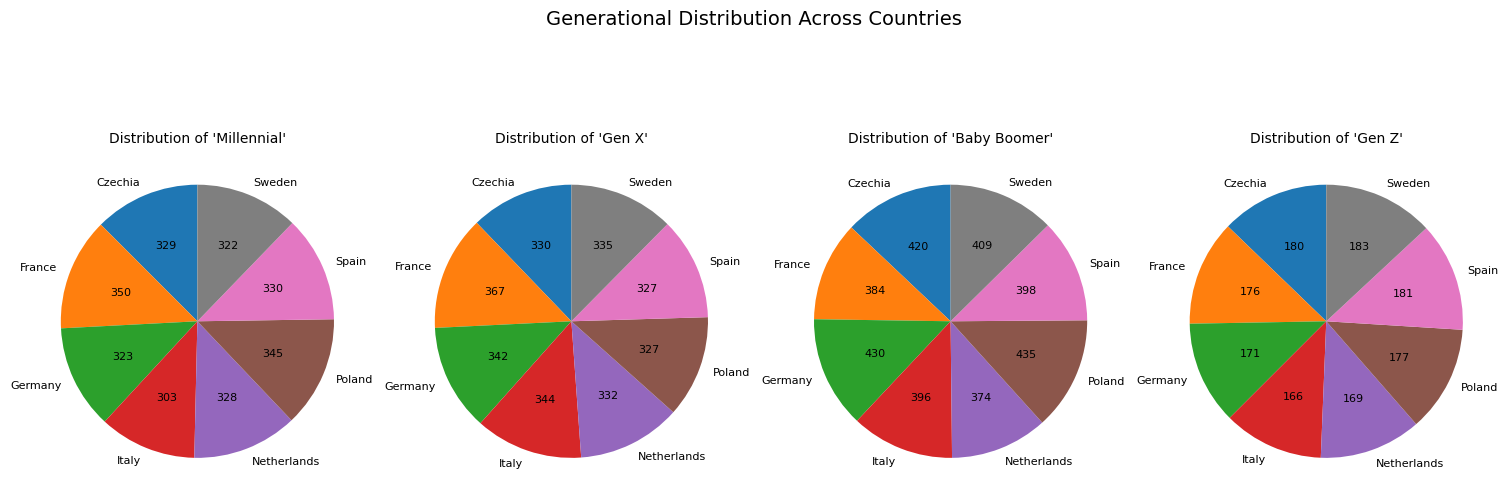

In [5]:
gen_ar = df['generation'].unique()
cg = df.groupby('country')['generation'].apply(list)

fig, axes = plt.subplots(nrows=1, ncols=len(gen_ar), figsize=(15, 6), constrained_layout=True)

for i, gen in enumerate(gen_ar):
    gen_counts = cg.apply(lambda x: x.count(gen))

    countries = np.array(gen_counts.keys())
    counts = np.array(gen_counts.values)

    axes[i].pie(
        counts,
        labels=countries,
        autopct=lambda p: f'{int(p * sum(counts) / 100)}',
        startangle=90,
        textprops={'fontsize': 8}
    )
    axes[i].set_title(f"Distribution of '{gen}'", fontsize=10)

plt.suptitle("Generational Distribution Across Countries", fontsize=14, y=1.02)

plt.show()

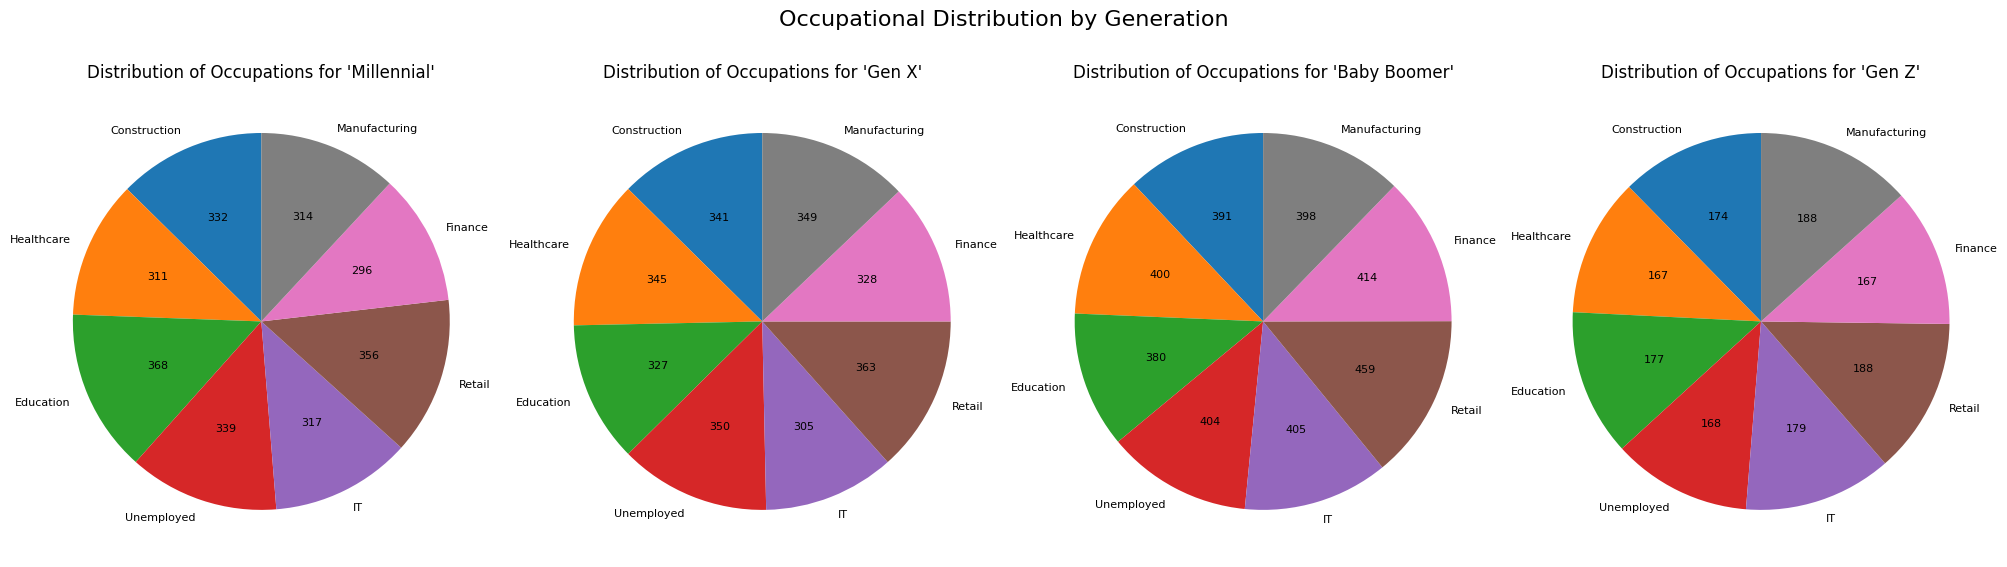

In [6]:
cg = df.groupby('generation')['occupation'].apply(list)

fig, axes = plt.subplots(nrows=1, ncols=len(gen_ar), figsize=(20, 6), constrained_layout=True)

for i, gen in enumerate(gen_ar):
    occupation_list = cg[gen] 
    occupation_counts = {occ: occupation_list.count(occ) for occ in set(occupation_list)} 

    countries = list(occupation_counts.keys())
    counts = list(occupation_counts.values())

    axes[i].pie(
        counts,
        labels=countries,
        autopct=lambda p: f'{int(p * sum(counts) / 100)}',  
        startangle=90,
        textprops={'fontsize': 8}
    )
    axes[i].set_title(f"Distribution of Occupations for '{gen}'", fontsize=12)

plt.suptitle("Occupational Distribution by Generation", fontsize=16, y=1.02)

plt.show()

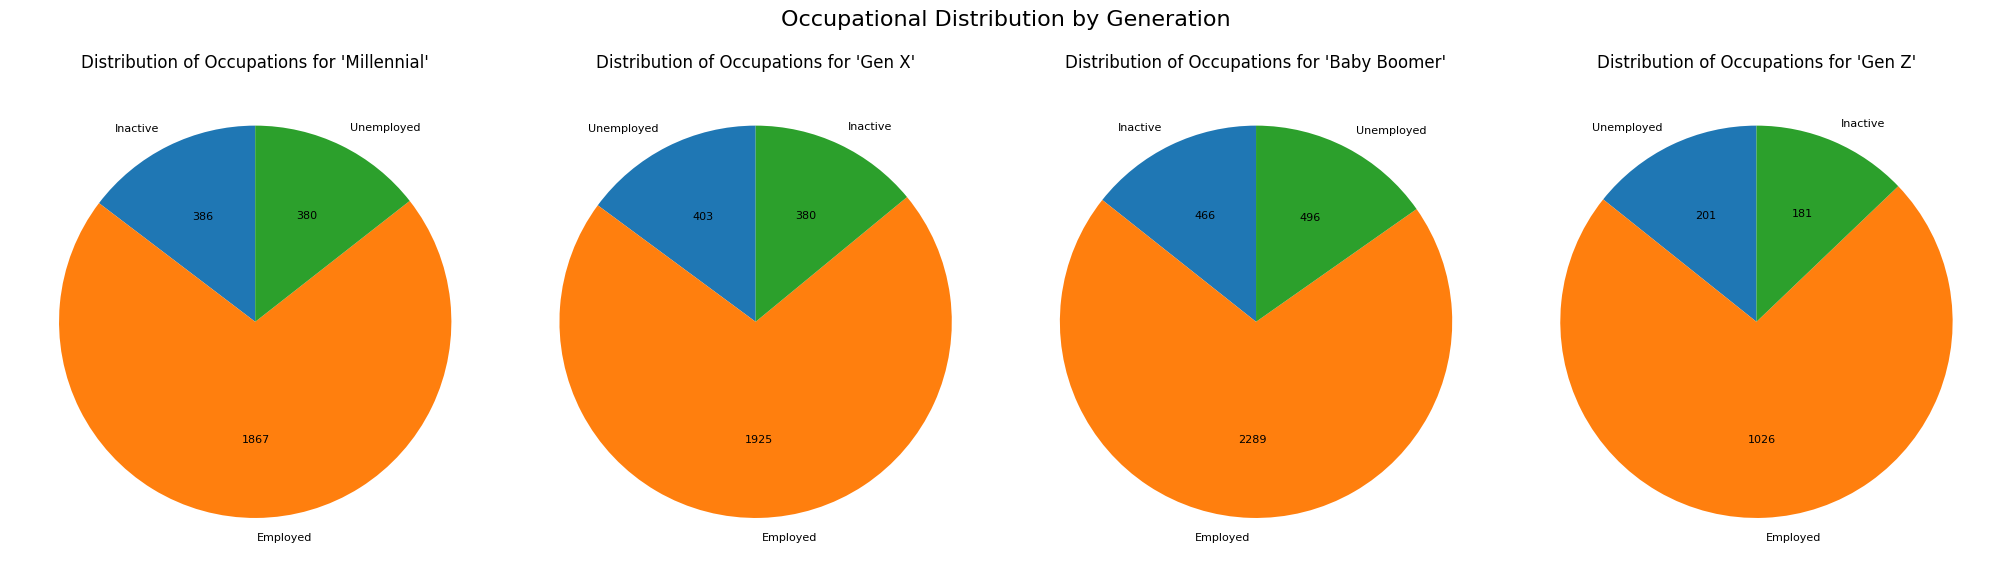

In [ ]:
cg = df.groupby('generation')['employment_status'].apply(list)

fig, axes = plt.subplots(nrows=1, ncols=len(gen_ar), figsize=(20, 6), constrained_layout=True)

for i, gen in enumerate(gen_ar):
    occupation_list = cg[gen] 
    occupation_counts = {occ: occupation_list.count(occ) for occ in set(occupation_list)} 

    countries = list(occupation_counts.keys())
    counts = list(occupation_counts.values())

    axes[i].pie(
        counts,
        labels=countries,
        autopct=lambda p: f'{int(p * sum(counts) / 100)}',  
        startangle=90,
        textprops={'fontsize': 8}
    )
    axes[i].set_title(f"Distribution of Employment status for '{gen}'", fontsize=12)

plt.suptitle("Occupational Distribution by Generation", fontsize=16, y=1.02)

plt.show()




Salary Statistics by Generation:
    generation         Mean  Median  Min     Max
0  Baby Boomer  2199.342971  2198.0  0.0  5211.0
1        Gen X  2219.200886  2206.0  0.0  6069.0
2        Gen Z  2188.461648  2179.0  0.0  4837.0
3   Millennial  2183.091910  2182.0  0.0  5814.0


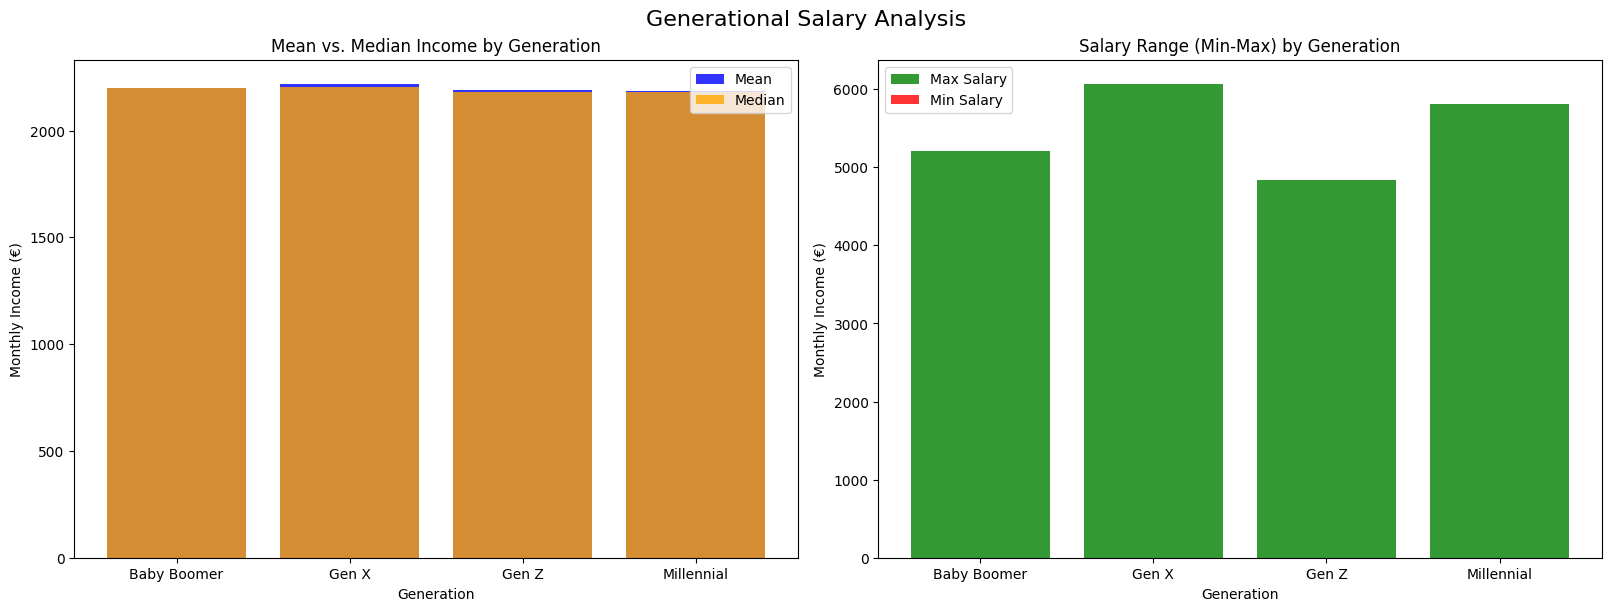

In [25]:
stats = df.groupby('generation')['monthly_income_eur'].agg(
    Mean='mean',
    Median='median',
    Min='min',
    Max='max'
).reset_index()

print("Salary Statistics by Generation:")
print(stats)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), constrained_layout=True)

axes[0].bar(stats['generation'], stats['Mean'], label='Mean', alpha=0.8, color='blue')
axes[0].bar(stats['generation'], stats['Median'], label='Median', alpha=0.8, color='orange')
axes[0].set_title("Mean vs. Median Income by Generation")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Monthly Income (€)")
axes[0].legend()

axes[1].bar(stats['generation'], stats['Max'], label='Max Salary', alpha=0.8, color='green')
axes[1].bar(stats['generation'], stats['Min'], label='Min Salary', alpha=0.8, color='red')
axes[1].set_title("Salary Range (Min-Max) by Generation")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Monthly Income (€)")
axes[1].legend()

plt.suptitle("Generational Salary Analysis", fontsize=16)
plt.show()

Most Common Number of Months to First Job by Generation:
    generation  Most_Common
0  Baby Boomer           29
1        Gen X           14
2        Gen Z            3
3   Millennial           29


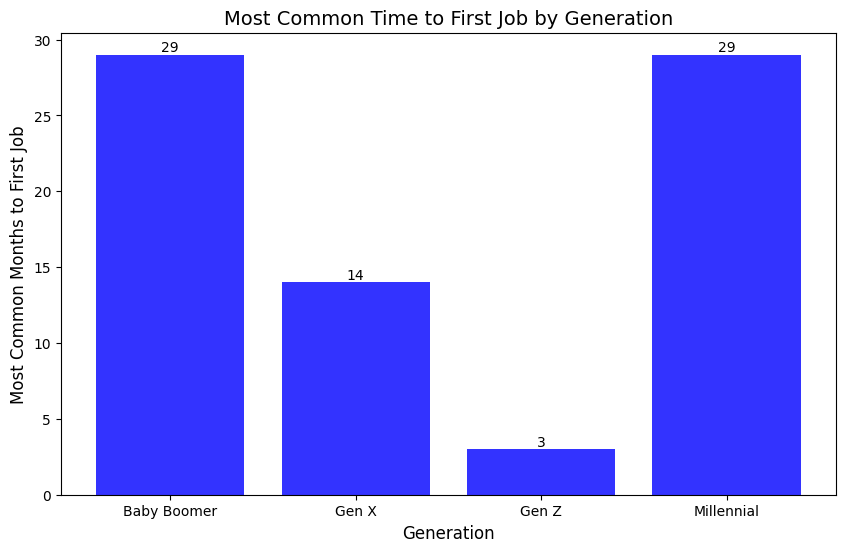

In [ ]:

most_common_months = df.groupby('generation')['months_to_first_job'].agg(
    Most_Common=lambda x: x.mode()[0]  
).reset_index()

print("Most Common Number of Months to First Job by Generation:")
print(most_common_months)

plt.figure(figsize=(10, 6))
plt.bar(most_common_months['generation'], most_common_months['Most_Common'], color='blue', alpha=0.8)
plt.title("Most Common Time to First Job by Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Most Common Months to First Job", fontsize=12)

for index, row in most_common_months.iterrows():
    plt.text(row['generation'], row['Most_Common'], row['Most_Common'], 
             ha='center', va='bottom', fontsize=10)

plt.show()

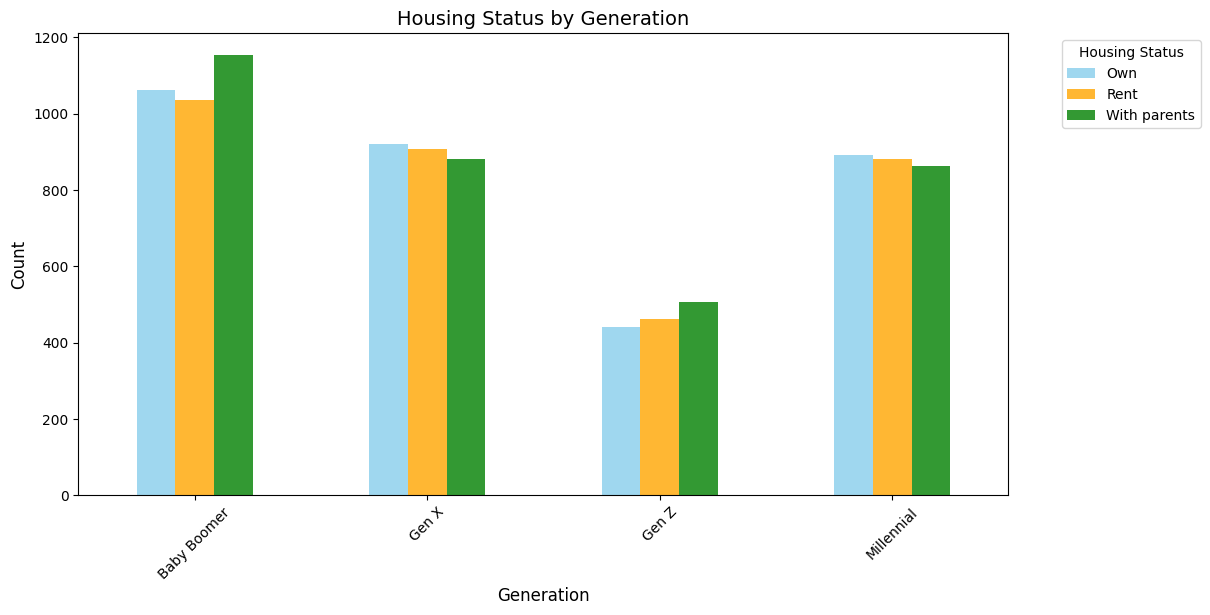

In [32]:
housing_counts = df.groupby(['generation', 'housing_status']).size().unstack(fill_value=0)

housing_counts.plot(kind='bar', figsize=(12, 6), alpha=0.8, color=['skyblue', 'orange', 'green', 'red'])
plt.title("Housing Status by Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.legend(title="Housing Status", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

plt.show()

Most Common Job Satisfaction Level by Generation:
    generation  Most_Common
0  Baby Boomer            1
1        Gen X            1
2        Gen Z            1
3   Millennial            2


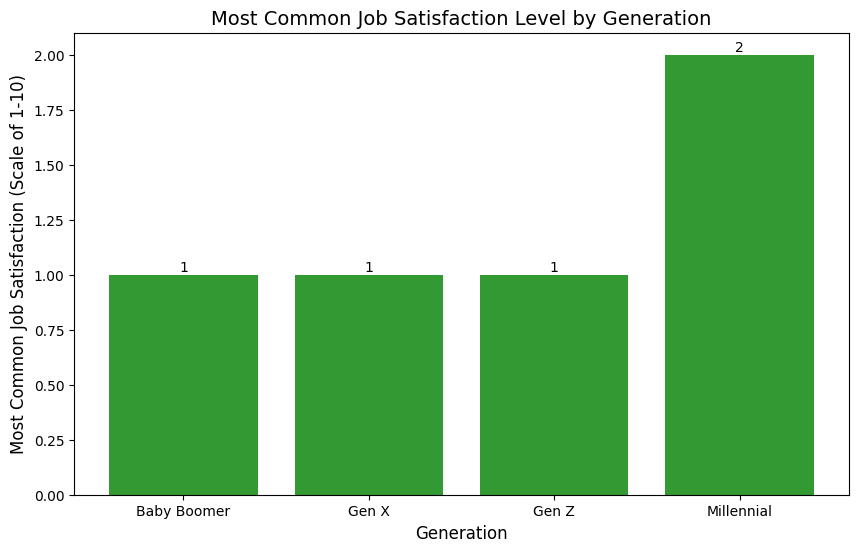

In [37]:
most_common_satisfaction = df.groupby('generation')['job_satisfaction'].agg(
    Most_Common=lambda x: x.mode()[0]  
).reset_index()

print("Most Common Job Satisfaction Level by Generation:")
print(most_common_satisfaction)

plt.figure(figsize=(10, 6))
plt.bar(most_common_satisfaction['generation'], most_common_satisfaction['Most_Common'], color='green', alpha=0.8)
plt.title("Most Common Job Satisfaction Level by Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Most Common Job Satisfaction (Scale of 1-10)", fontsize=12)

for index, row in most_common_satisfaction.iterrows():
    plt.text(row['generation'], row['Most_Common'], row['Most_Common'], 
             ha='center', va='bottom', fontsize=10)

plt.show()

Most Common Life Satisfaction Level by Generation:
    generation  Most_Common
0  Baby Boomer            4
1        Gen X            5
2        Gen Z            8
3   Millennial           10


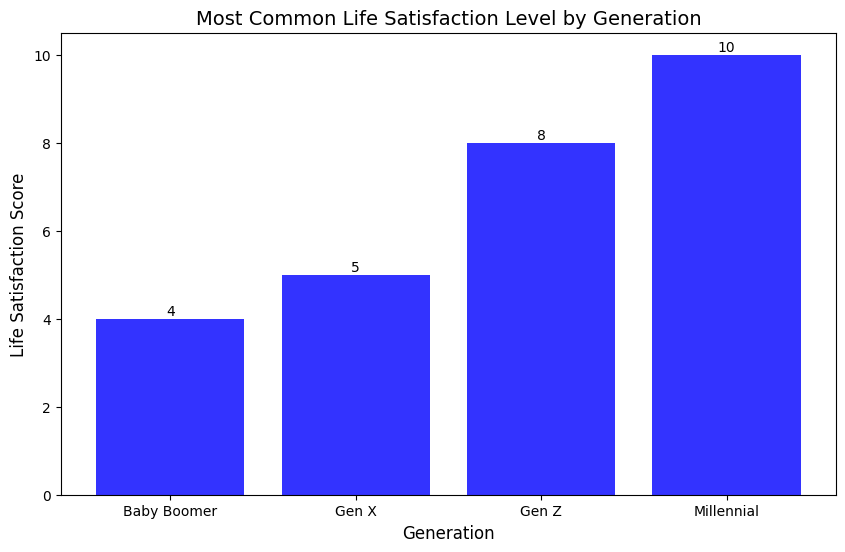

In [ ]:
most_common_life_satisfaction = df.groupby('generation')['life_satisfaction'].agg(
    Most_Common=lambda x: x.mode()[0]
).reset_index()

print("Most Common Life Satisfaction Level by Generation:")
print(most_common_life_satisfaction)

plt.figure(figsize=(10, 6))
plt.bar(most_common_life_satisfaction['generation'], most_common_life_satisfaction['Most_Common'], color='blue', alpha=0.8)
plt.title("Most Common Life Satisfaction Level by Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Life Satisfaction Score", fontsize=12)

for index, row in most_common_life_satisfaction.iterrows():
    plt.text(row['generation'], row['Most_Common'], row['Most_Common'], 
             ha='center', va='bottom', fontsize=10)

plt.show()

Most Common Economic Anxiety Level by Generation:
    generation  Most_Common
0  Baby Boomer            1
1        Gen X           10
2        Gen Z            4
3   Millennial            5


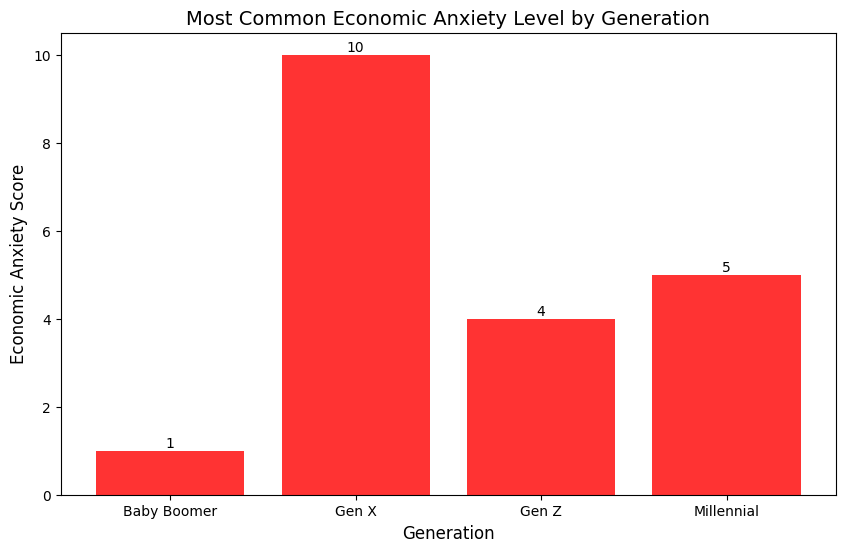

In [41]:
most_common_economic_anxiety = df.groupby('generation')['economic_anxiety'].agg(
    Most_Common=lambda x: x.mode()[0]
).reset_index()

print("Most Common Economic Anxiety Level by Generation:")
print(most_common_economic_anxiety)

plt.figure(figsize=(10, 6))
plt.bar(most_common_economic_anxiety['generation'], most_common_economic_anxiety['Most_Common'], color='red', alpha=0.8)
plt.title("Most Common Economic Anxiety Level by Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Economic Anxiety Score", fontsize=12)

for index, row in most_common_economic_anxiety.iterrows():
    plt.text(row['generation'], row['Most_Common'], row['Most_Common'], 
             ha='center', va='bottom', fontsize=10)

plt.show()

Most Common Age at First Job by Generation:
    generation  Most_Common
0  Baby Boomer           27
1        Gen X           19
2        Gen Z           24
3   Millennial           29


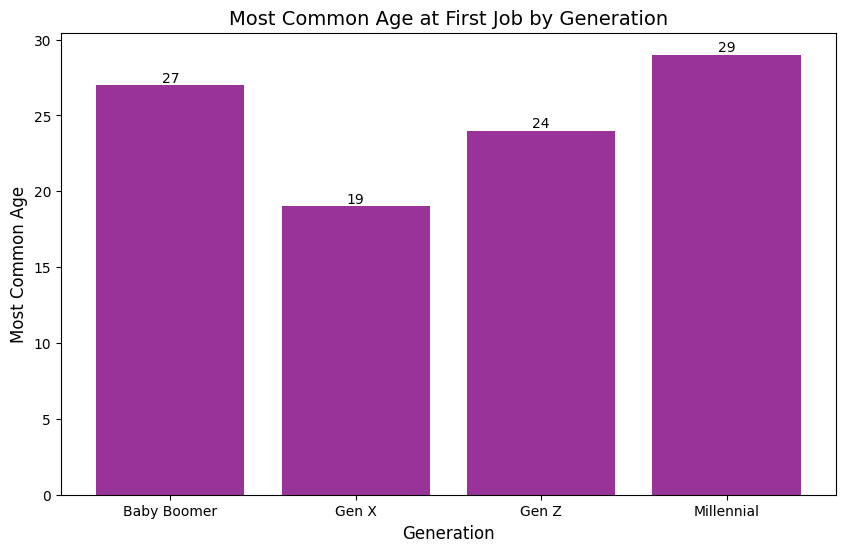

: 

In [ ]:
most_common_age_first_job = df.groupby('generation')['age_first_job'].agg(
    Most_Common=lambda x: x.mode()[0]  # Take the first mode if more than one
).reset_index()

print("Most Common Age at First Job by Generation:")
print(most_common_age_first_job)

plt.figure(figsize=(10, 6))
plt.bar(most_common_age_first_job['generation'], most_common_age_first_job['Most_Common'], color='purple', alpha=0.8)
plt.title("Most Common Age at First Job by Generation", fontsize=14)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("Most Common Age", fontsize=12)

for index, row in most_common_age_first_job.iterrows():
    plt.text(row['generation'], row['Most_Common'], row['Most_Common'], 
             ha='center', va='bottom', fontsize=10)

plt.show()